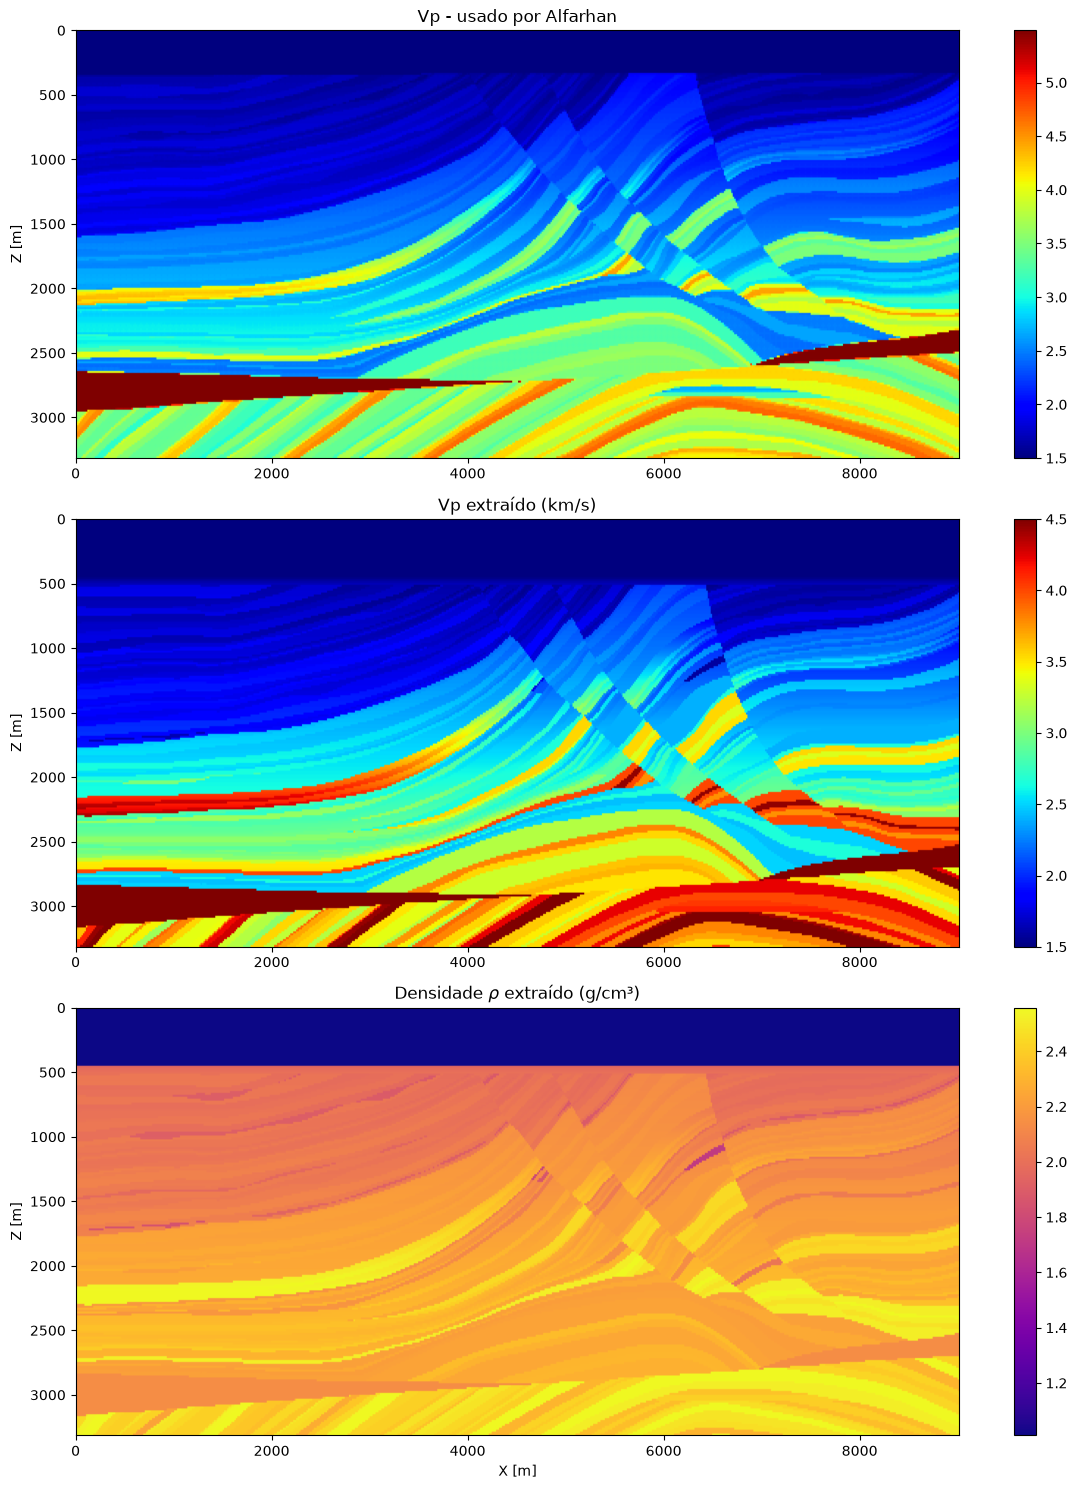

In [14]:
%pip install obspy

import pathlib
import obspy
import numpy as np
import matplotlib.pyplot as plt
from skimage.transform import resize

# Caminhos dos arquivos
data_dir = pathlib.Path("../data").resolve()
model_dir = data_dir / "elastic-marmousi-model" / "model"

vp_segy_path  = list(model_dir.glob("*P-WAVE*.segy"))[0]
rho_segy_path = list(model_dir.glob("*DENSITY*.segy"))[0]

# Carregar o .bin de referência
velocity_file = data_dir / "Marm.bin"
marm_bin = np.fromfile(velocity_file, dtype=np.float32)

# Verifica se precisa de transposição (caso tenha sido salvo via Fortran/MATLAB)
if marm_bin.size == 221 * 601:
    marm_bin = marm_bin.reshape(221, 601)
else:
    raise ValueError(f"Tamanho do arquivo .bin ({marm_bin.size}) difere de 221x601!")

if marm_bin.max() > 100:
    marm_bin = marm_bin / 1000.0

# Ler SEG-Y original de alta resolução
st_vp  = obspy.read(str(vp_segy_path))
st_rho = obspy.read(str(rho_segy_path))

vp_full  = np.array([tr.data for tr in st_vp]).T
rho_full = np.array([tr.data for tr in st_rho]).T

if vp_full.max() > 100:
    vp_full = vp_full / 1000.0
if rho_full.max() > 100:
    rho_full = rho_full / 1000.0

# Definir o corte exato manualmente
dx_segy = 1.25  # Amostragem espacial do SEG-Y original (1.25 m)

# Offset exato para alinhar a cunha vermelha no X = 0m
x_start_m = 3900.0  
x_end_m   = x_start_m + 9015.0  # 601 * 15m
z_max_m   = 3315.0              # 221 * 15m

ix_start = int(x_start_m / dx_segy)
ix_end   = int(x_end_m / dx_segy)
iz_max   = int(z_max_m / dx_segy)

# Cortar e Redimensionar para (221, 601)
vp_cropped  = vp_full[:iz_max, ix_start:ix_end]
rho_cropped = rho_full[:iz_max, ix_start:ix_end]

model_true = resize(vp_cropped, (221, 601), order=0, mode='edge', anti_aliasing=False)
rho_true   = resize(rho_cropped, (221, 601), order=0, mode='edge', anti_aliasing=False)

# Define o modelo e os parâmetros de aquisição geométrica
par = {
    'nx': 601,                     # Número de pontos na direção X (horizontal)
    'dx': 0.015,                   # Espaçamento da malha em X
    'ox': 0,                       # Origem do eixo X
    
    'nz': 221,                     # Número de pontos na direção Z (profundidade)
    'dz': 0.015,                   # Espaçamento da malha em Z
    'oz': 0,                       # Origem do eixo Z
    
    'num_shots': 30,               # Número total de tiros (fontes)
    'ds': 0.3,                     # Espaçamento entre os tiros
    'os': 0,                       # Posição inicial do primeiro tiro
    'sz': 0,                       # Profundidade das fontes
    
    'num_receivers_per_shot': 300, # Número de receptores por tiro
    'dr': 0.03,                    # Espaçamento entre os receptores
    'orec': 0,                     # Posição inicial do primeiro receptor
    'rz': 0,                       # Profundidade dos receptores
    
    'nt': 5000,                    # Número de passos no tempo (amostras temporais)
    'dt': 0.001,                   # Intervalo de amostragem de tempo (taxa de amostragem)
    'ot': 0,                       # Tempo inicial
    
    'freq': 5,                     # Frequência central da fonte (Ricker)
    'num_sources_per_shot': 1,     # Número de fontes por tiro
    'num_dims': 2,                 # Quantidade de dimensões (2D)
    'num_batches': 30,             # Número de lotes para o processamento
    'FWI_itr': 100                 # Número de iterações da FWI
}

# Extensão espacial em metros [Xmin, Xmax, Zmax, Zmin]
extent_m = [0, par['nx'] * par['dx'] * 1000, par['nz'] * par['dz'] * 1000, 0]

fig, ax = plt.subplots(3, 1, figsize=(12, 15))

# Plot 1: Arquivo .bin de referência (Alfarhan)
vmin1, vmax1 = np.percentile(marm_bin, [2, 98])
im0 = ax[0].imshow(marm_bin, cmap='jet', vmin=vmin1, vmax=vmax1, extent=extent_m, aspect='auto')
ax[0].set_title("Vp - usado por Alfarhan")
ax[0].set_ylabel("Z [m]")
plt.colorbar(im0, ax=ax[0])

# Plot 2: Vp Extraído do SEG-Y
vmin2, vmax2 = np.percentile(model_true, [2, 98])
im1 = ax[1].imshow(model_true, cmap='jet', vmin=vmin2, vmax=vmax2, extent=extent_m, aspect='auto')
ax[1].set_title("Vp extraído (km/s)")
ax[1].set_ylabel("Z [m]")
plt.colorbar(im1, ax=ax[1])

# Plot 3: Densidade Rho Correspondente
vmin3, vmax3 = np.percentile(rho_true, [2, 98])
im2 = ax[2].imshow(rho_true, cmap='plasma', vmin=vmin3, vmax=vmax3, extent=extent_m, aspect='auto')
ax[2].set_title(r"Densidade $\rho$ extraído (g/cm³)")
ax[2].set_xlabel("X [m]")
ax[2].set_ylabel("Z [m]")
plt.colorbar(im2, ax=ax[2])

plt.tight_layout()
plt.show()